# Comprensión y Análisis Exploratorio de Datos (EDA)

**Proyecto:** Modelo predictivo de comportamiento de pago de créditos.

**Objetivo de este notebook:** realizar la exploración y comprensión detallada del dataset de créditos históricos (`Base_de_datos.xlsx`), como paso previo a la construcción del modelo predictivo. Se busca caracterizar las variables, tratar valores nulos, corregir tipos de datos, y analizar las relaciones entre variables (univariable, bivariable y multivariable) respecto a la variable objetivo `Pago_atiempo`.

Este notebook toma como entrada el resultado de `Cargar_datos.ipynb`.

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Carga de datos

Se replica la carga realizada en `Cargar_datos.ipynb`, ya que cada notebook debe poder ejecutarse de forma independiente. Se usa la misma resolución de rutas robusta (búsqueda de la raíz del repo por archivo marca), en vez de una ruta relativa fija como `Path("..")`, que depende de desde dónde se lance el kernel.

In [3]:
def find_repo_root(marker: str = "requirements.txt", start: Path = None) -> Path:
    """Busca hacia arriba desde 'start' (o el directorio actual) hasta encontrar
    la carpeta que contiene 'marker'. Es independiente de desde donde se lance el kernel."""
    current = (start or Path.cwd()).resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(
        f"No se encontro '{marker}' en ningun directorio padre a partir de {current}"
    )

REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "Base_de_datos.xlsx"

df = pd.read_excel(DATA_PATH)
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones del dataset: 10763 filas x 23 columnas


## 2. Exploración inicial de datos

### 2.1 Descripción general

In [4]:
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

**Observación inicial:** el dataset contiene 23 columnas. La mayoría son numéricas (`int64`/`float64`), hay una columna de fecha (`fecha_prestamo`), una columna de texto categórico limpio (`tipo_laboral`) y una columna problemática (`tendencia_ingresos`) que se analiza en detalle más abajo.

### Diccionario de variables

Provisto junto con el dataset, como referencia para la interpretación de negocio de cada columna:

| Variable | Interpretación |
|---|---|
| `tipo_credito` | Código categórico del tipo de crédito solicitado. El valor numérico en sí no tiene relevancia de negocio, solo distingue categorías. |
| `fecha_prestamo` | Fecha en que se registró/otorgó el préstamo. |
| `capital_prestado` | Monto de capital originalmente prestado. |
| `plazo_meses` | Plazo acordado para cancelar el préstamo, en meses. |
| `edad_cliente` | Edad del cliente al momento del préstamo. |
| `tipo_laboral` | Situación laboral del cliente (`Empleado` / `Independiente`). |
| `salario_cliente` | Ingreso/salario declarado por el cliente. |
| `total_otros_prestamos` | Monto total de otros préstamos/deudas del cliente. |
| `cuota_pactada` | Valor de la cuota periódica acordada. |
| `puntaje` | Score utilizado para evaluar al cliente (fuente no explicitada). |
| `puntaje_datacredito` | Score crediticio proveniente de la central de riesgo DataCrédito. |
| `cant_creditosvigentes` | Cantidad de créditos vigentes del cliente. |
| `huella_consulta` | Cantidad de consultas realizadas sobre el historial crediticio del cliente (cada solicitud de crédito en cualquier entidad genera una consulta). |
| `saldo_mora` | Monto de obligaciones actualmente vencidas/en mora. |
| `saldo_total` | Saldo total de las obligaciones reportadas. |
| `saldo_principal` | Saldo pendiente del capital principal, esté o no vencido. |
| `saldo_mora_codeudor` | Monto en mora en obligaciones donde el cliente figura como codeudor. |
| `creditos_sectorFinanciero` | Cantidad de créditos en el sector financiero. |
| `creditos_sectorCooperativo` | Cantidad de créditos en el sector cooperativo. |
| `creditos_sectorReal` | Cantidad de créditos en el sector real/comercial (ej. prendarios, hipotecarios). |
| `promedio_ingresos_datacredito` | Promedio de ingresos reportado/estimado por DataCrédito. |
| `tendencia_ingresos` | Tendencia de los ingresos del cliente en el tiempo: `Creciente`, `Estable` o `Decreciente`. |
| `Pago_atiempo` | Variable objetivo binaria: `1` = paga a tiempo, `0` = no paga a tiempo. |


### 2.2 Caracterización de las variables

Antes de la tabla, dos aclaraciones sobre las categorías usadas:
- **Dicotómica**: variable categórica que solo puede tomar **2** valores posibles (ej. Sí/No, 0/1).
- **Politómica**: variable categórica que puede tomar **más de 2** valores posibles.

| Variable | Tipo |
|---|---|
| `tipo_credito` | Categórica nominal politómica (6 categorías) |
| `fecha_prestamo` | Fecha |
| `capital_prestado`, `salario_cliente`, `cuota_pactada`, `saldo_total`, `saldo_principal`, `promedio_ingresos_datacredito`, `puntaje`, `puntaje_datacredito` | Numéricas continuas |
| `plazo_meses`, `edad_cliente`, `cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero`, `creditos_sectorCooperativo`, `creditos_sectorReal` | Numéricas discretas |
| `saldo_mora`, `saldo_mora_codeudor` | Numéricas continuas (mayormente 0, poca variabilidad) |
| `tipo_laboral` | Categórica nominal **dicotómica** (Independiente / Empleado) |
| `tendencia_ingresos` | Categórica nominal politómica (requiere limpieza, ver 2.4) |
| `Pago_atiempo` | Categórica **dicotómica** (0/1) — **variable objetivo** |

No se identifican variables ordinales (no hay categorías con orden inherente).

### 2.3 Revisión de nulos y duplicados

In [6]:
nulos = df.isnull().sum()
nulos_pct = (df.isnull().mean() * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje_%': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('nulos', ascending=False)
resumen_nulos

,nulos,porcentaje_%
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


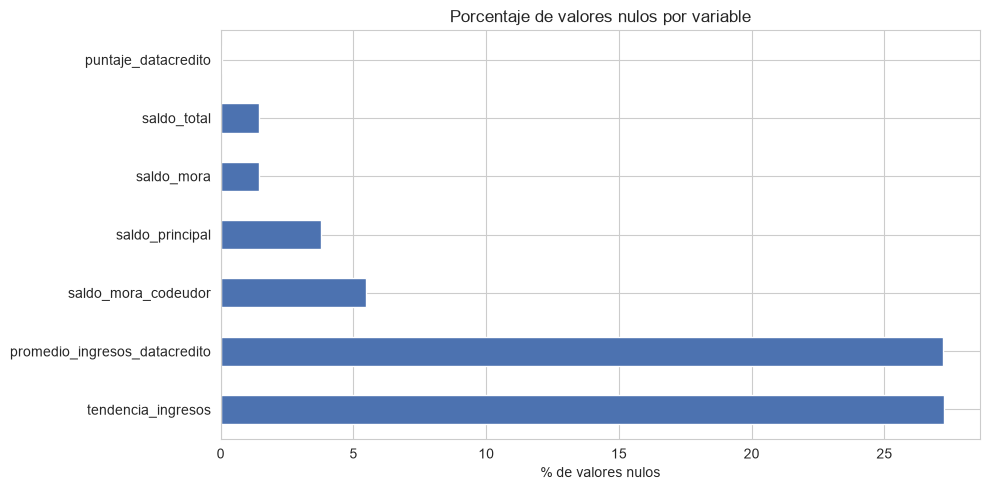

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
resumen_nulos['porcentaje_%'].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de valores nulos por variable')
plt.tight_layout()
plt.show()

**Interpretación:** las variables con mayor proporción de nulos son `tendencia_ingresos` y `promedio_ingresos_datacredito` (~27% cada una), seguidas de `saldo_mora_codeudor` (~5.5%), `saldo_principal` (~3.8%) y `saldo_mora`/`saldo_total` (~1.5%). El resto de las variables no presenta nulos.

In [8]:
# ¿Los nulos de tendencia_ingresos y promedio_ingresos_datacredito ocurren en las mismas filas?
null_ingresos = df['promedio_ingresos_datacredito'].isnull()
null_tendencia = df['tendencia_ingresos'].isnull()

print(f"Nulos en promedio_ingresos_datacredito: {null_ingresos.sum()}")
print(f"Nulos en tendencia_ingresos: {null_tendencia.sum()}")
print(f"Nulos en ambas columnas, en las mismas filas: {(null_ingresos & null_tendencia).sum()}")

Nulos en promedio_ingresos_datacredito: 2930
Nulos en tendencia_ingresos: 2932
Nulos en ambas columnas, en las mismas filas: 2930


**Hallazgo importante:** prácticamente el 100% de los nulos de `promedio_ingresos_datacredito` coincide, fila por fila, con nulos en `tendencia_ingresos`. Esto no parece un problema de integridad interno de la base, sino más bien que ambas variables dependen de una misma fuente externa (la consulta a DataCrédito), que simplemente no devolvió resultado para ese subconjunto de clientes. Por eso no se recomienda eliminar estas filas ni imputarlas ingenuamente: conviene tratarlas como un bloque conjunto y, en la etapa de feature engineering, considerar una bandera de "sin información de DataCrédito" en vez de imputar valores artificiales.

In [9]:
# Duplicados y estado del target (control faltante detectado en la revisión de pares)
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

nulos_target = df['Pago_atiempo'].isnull().sum()
print(f"Nulos en la variable objetivo (Pago_atiempo): {nulos_target}")

Filas duplicadas: 0
Nulos en la variable objetivo (Pago_atiempo): 0


**No se encontraron filas duplicadas ni nulos en la variable objetivo.**

### 2.4 Unificación de la representación de valores nulos

Antes de tratar los nulos "clásicos" (`NaN`), se detectó un problema de calidad de datos en la columna `tendencia_ingresos`: además de sus 3 categorías esperadas (`Estable`, `Creciente`, `Decreciente`), contiene valores **numéricos** que no corresponden a una tendencia (parecen ser datos de otra columna que se filtraron por error, ej. montos como `168750` o `-566272`).

Estos valores numéricos no son técnicamente nulos, pero **funcionalmente lo son** para el propósito de esta variable categórica: no aportan información válida de tendencia de ingresos. Se unifican como nulos para dejar la columna limpia.

In [10]:
categorias_validas = ['Estable', 'Creciente', 'Decreciente']

# Cantidad de valores no válidos (distintos a las 3 categorías esperadas y no nulos)
mask_invalido = df['tendencia_ingresos'].notna() & ~df['tendencia_ingresos'].isin(categorias_validas)
print(f"Valores no válidos detectados en 'tendencia_ingresos': {mask_invalido.sum()}")
print("Ejemplos:", df.loc[mask_invalido, 'tendencia_ingresos'].unique()[:10])

# Se crea una versión limpia de la variable, unificando estos casos como NaN
df['tendencia_ingresos_limpia'] = df['tendencia_ingresos'].where(~mask_invalido, np.nan)
df['tendencia_ingresos_limpia'] = df['tendencia_ingresos_limpia'].where(
    df['tendencia_ingresos_limpia'].isin(categorias_validas), np.nan
)

print()
print("Distribución luego de la limpieza:")
print(df['tendencia_ingresos_limpia'].value_counts(dropna=False))

Valores no válidos detectados en 'tendencia_ingresos': 58
Ejemplos: [8315 0 158042 3978 9147 168750 -28589 1000000 -566272 24702]

Distribución luego de la limpieza:
tendencia_ingresos_limpia
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64


**Regla de validación derivada:** `tendencia_ingresos` solo debe aceptar los valores `{Estable, Creciente, Decreciente}` o nulo. Cualquier otro valor debe tratarse como error de carga/origen y reportarse, no imputarse silenciosamente como si fuera válido.

El resto de las columnas numéricas no presenta placeholders sospechosos (no se encontraron valores negativos donde no corresponde, ni códigos tipo `-1`/`9999` usados como "nulo disfrazado"), por lo que sus nulos ya están correctamente representados como `NaN` por pandas.

### 2.5 Eliminación de variables irrelevantes

Se revisaron las 23 variables originales. No se identifican columnas evidentemente irrelevantes para el objetivo del análisis (todas están conceptualmente vinculadas a la evaluación de riesgo crediticio: identificación del crédito, historial financiero, ingresos, comportamiento de pago). 

Se mantiene la columna original `tendencia_ingresos` junto a la nueva `tendencia_ingresos_limpia` únicamente para trazabilidad de la corrección — en una etapa posterior (feature engineering) se recomienda quedarse solo con la versión limpia.

No se eliminan variables en esta etapa.

### 2.6 Conversión de tipos de datos

Se ajustan los tipos para que cada columna tenga un tipo de dato uniforme y semánticamente correcto.

In [11]:
# Variables categóricas nominales
df['tipo_credito'] = df['tipo_credito'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')
df['tendencia_ingresos_limpia'] = df['tendencia_ingresos_limpia'].astype('category')

# Variable objetivo, se deja como int (0/1) para el análisis pero se registra como dicotómica
df['Pago_atiempo'] = df['Pago_atiempo'].astype('int8')

# Fecha (ya viene como datetime desde la carga, se valida)
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'])

# Variables de conteo: el diccionario de datos exige explícitamente que sean enteras
cols_conteo = ['cant_creditosvigentes', 'huella_consulta', 'creditos_sectorFinanciero',
               'creditos_sectorCooperativo', 'creditos_sectorReal']
for c in cols_conteo:
    df[c] = df[c].astype('int64')

print("Tipos de dato luego del ajuste:")
df.dtypes

Tipos de dato luego del ajuste:


tipo_credito                           category
fecha_prestamo                   datetime64[us]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

**Verificación contra el diccionario de datos:** las 5 variables de conteo (`cant_creditosvigentes`, `huella_consulta`, `creditos_sectorFinanciero`, `creditos_sectorCooperativo`, `creditos_sectorReal`) ya venían como enteras y sin nulos en el dataset original, por lo que se confirma el tipo `int64` explícitamente, cumpliendo con lo solicitado en el diccionario de datos.

In [12]:
# Validación de rangos esperados (reglas de validación de datos)
edades_anomalas = (~df['edad_cliente'].between(18, 90)).sum()
print(f"Registros con edad_cliente fuera del rango razonable (18-90): {edades_anomalas}")
print(f"Edad máxima registrada: {df['edad_cliente'].max()} | Edad mínima registrada: {df['edad_cliente'].min()}")

assert df['Pago_atiempo'].isin([0, 1]).all(), "Pago_atiempo debe ser binaria (0/1)"
assert (df['capital_prestado'] > 0).all(), "capital_prestado debe ser positivo"
print("\nValidaciones de Pago_atiempo y capital_prestado superadas correctamente.")
print("edad_cliente presenta valores anómalos que se documentan como hallazgo (ver regla de validación 3 más abajo).")

Registros con edad_cliente fuera del rango razonable (18-90): 150
Edad máxima registrada: 123 | Edad mínima registrada: 19

Validaciones de Pago_atiempo y capital_prestado superadas correctamente.
edad_cliente presenta valores anómalos que se documentan como hallazgo (ver regla de validación 3 más abajo).


**Hallazgo de calidad de datos:** se detectaron 150 registros con `edad_cliente` fuera de un rango razonable para una persona (hasta 123 años). Esto probablemente corresponde a errores de captura/origen. No se corrige en este notebook (es EDA, no limpieza definitiva), pero se documenta como regla de validación para la etapa de feature engineering.

## 3. Análisis univariable

In [13]:
df.describe()

,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,2025-04-16 23:06:02.111121,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
min,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668


### 3.1 Variables numéricas

Se analizan las variables numéricas más relevantes para el negocio: `capital_prestado`, `edad_cliente`, `salario_cliente`, `cuota_pactada`, `puntaje_datacredito` y `saldo_total`.

In [14]:
num_vars = ['capital_prestado', 'edad_cliente', 'salario_cliente', 'cuota_pactada', 'puntaje_datacredito', 'saldo_total']

resumen_num = pd.DataFrame({
    'media': df[num_vars].mean(),
    'mediana': df[num_vars].median(),
    'moda': df[num_vars].mode().iloc[0],
    'min': df[num_vars].min(),
    'max': df[num_vars].max(),
    'rango': df[num_vars].max() - df[num_vars].min(),
    'std': df[num_vars].std(),
    'varianza': df[num_vars].var(),
    'IQR': df[num_vars].quantile(0.75) - df[num_vars].quantile(0.25),
    'skewness': df[num_vars].skew(),
    'kurtosis': df[num_vars].kurt(),
})
resumen_num

,media,mediana,moda,min,max,rango,std,varianza,IQR,skewness,kurtosis
capital_prestado,2.434315e+06,1921920.0,1200000.0,360000.0,4.144415e+07,4.108415e+07,1.909643e+06,3.646735e+12,1860009.0,3.723884,35.318092
edad_cliente,4.394862e+01,42.0,40.0,19.0,1.230000e+02,1.040000e+02,1.506088e+01,2.268300e+02,20.0,1.934399,7.868936
salario_cliente,1.721643e+07,3000000.0,3000000.0,0.0,2.200000e+10,2.200000e+10,3.554767e+08,1.263637e+17,2875808.0,43.776664,2211.230120
cuota_pactada,2.436174e+05,182863.0,205990.0,23944.0,3.816752e+06,3.792808e+06,2.104937e+05,4.430760e+10,166792.0,3.793301,26.650757
puntaje_datacredito,7.807908e+02,791.0,0.0,-7.0,9.990000e+02,1.006000e+03,1.048780e+02,1.099940e+04,68.0,-5.644513,39.437798
saldo_total,4.593741e+04,16178.0,0.0,0.0,5.116066e+06,5.116066e+06,1.062698e+05,1.129327e+10,50084.0,20.197674,789.166702


**Lectura de medidas de forma:** `capital_prestado`, `salario_cliente`, `cuota_pactada` y `saldo_total` presentan **skewness positivo alto** (cola larga a la derecha), típico de variables monetarias — hay un grupo reducido de clientes con montos mucho más altos que el resto. `edad_cliente` está mucho más cerca de una distribución simétrica.

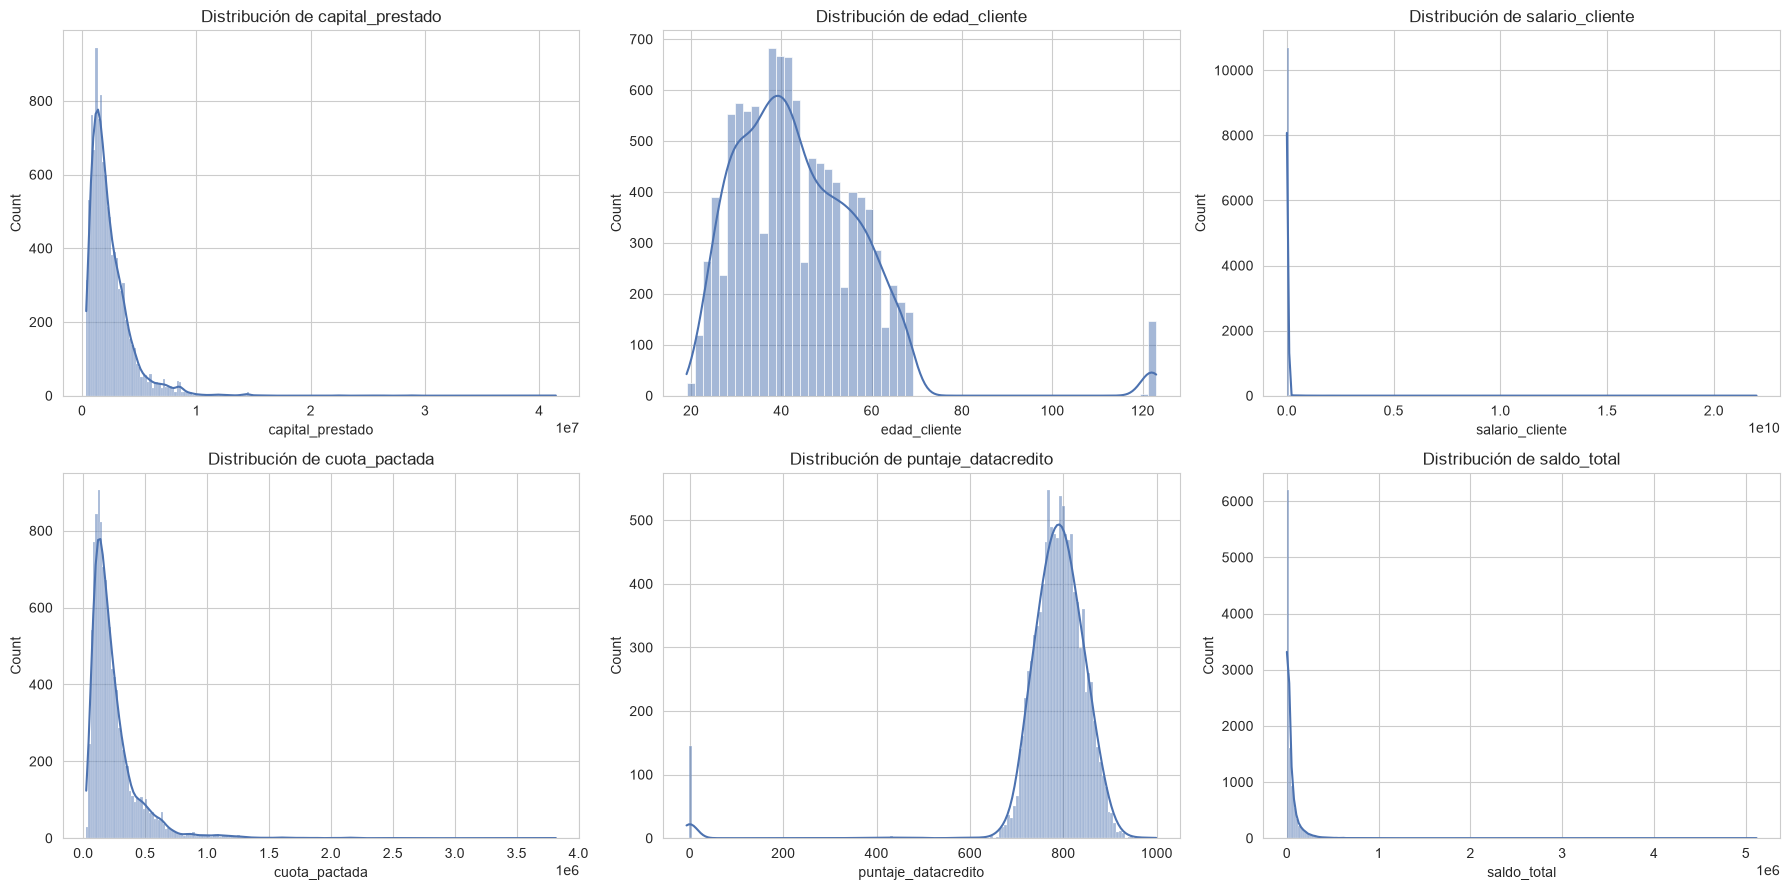

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), num_vars):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

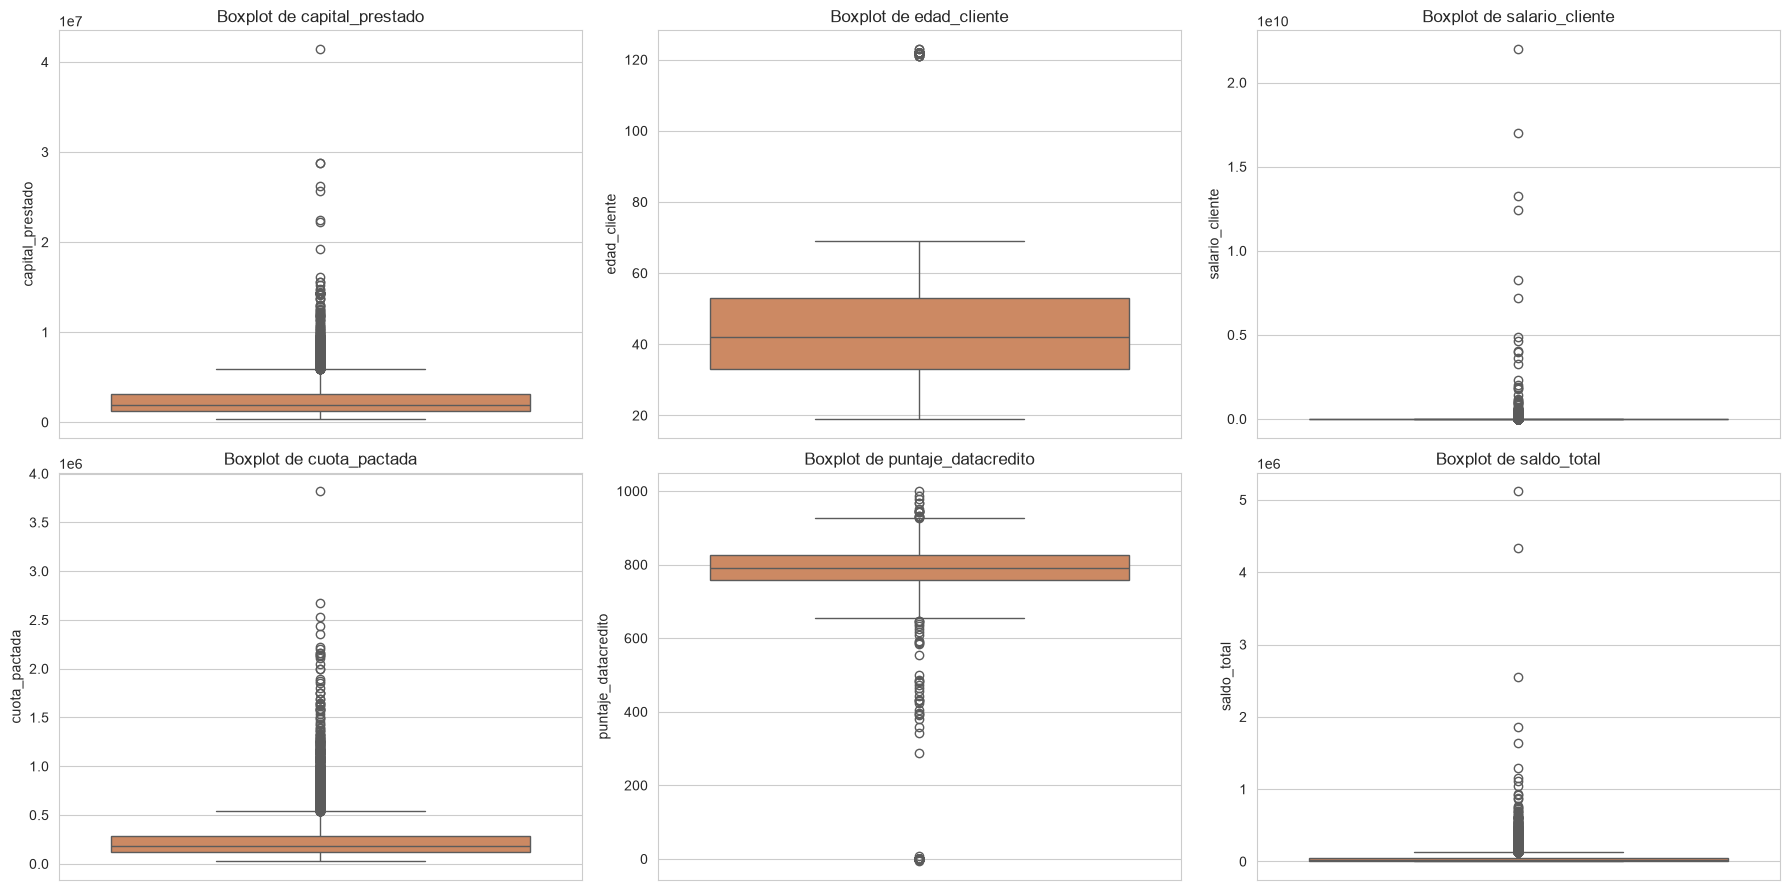

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), num_vars):
    sns.boxplot(y=df[col], ax=ax, color='#DD8452')
    ax.set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

**Interpretación de outliers:** los boxplots confirman la presencia de valores atípicos por encima del bigote superior en `capital_prestado`, `salario_cliente`, `cuota_pactada` y `saldo_total` — consistente con el skewness positivo detectado. `puntaje_datacredito` muestra una dispersión más acotada, sin outliers extremos. Estos outliers no se eliminan en esta etapa (es EDA, no limpieza final); se documentan como candidatos a revisión/transformación (ej. escalado logarítmico) en la etapa de feature engineering.

### 3.2 Variables categóricas

In [17]:
cat_vars = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos_limpia', 'Pago_atiempo']

for col in cat_vars:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- tipo_credito ---
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

--- tendencia_ingresos_limpia ---
tendencia_ingresos_limpia
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188
Name: count, dtype: int64

--- Pago_atiempo ---
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64



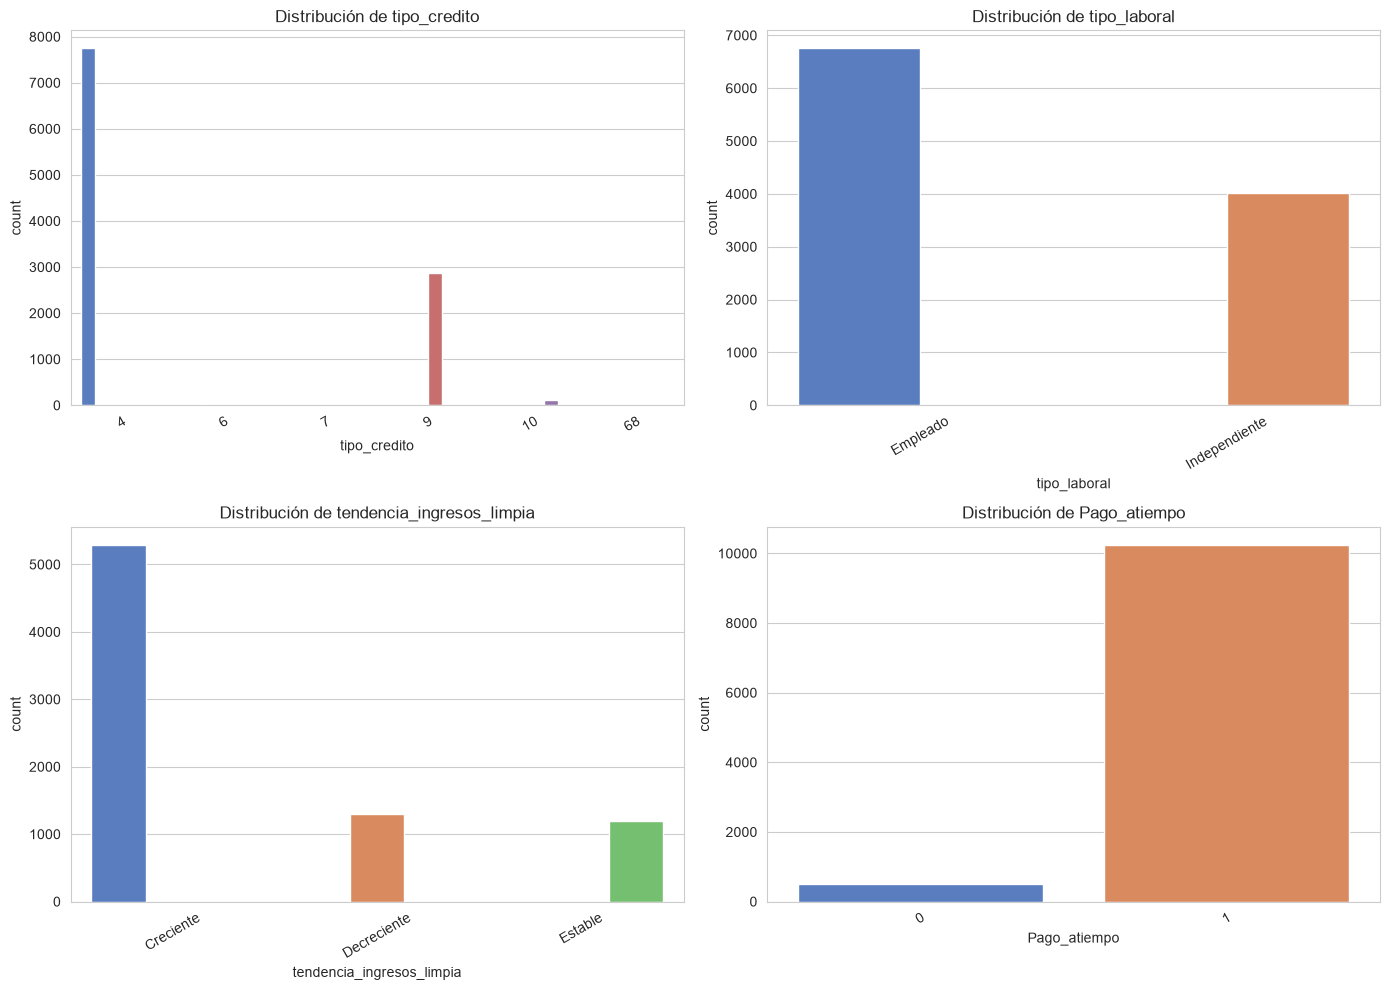

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), cat_vars):
    sns.countplot(x=df[col], ax=ax, palette='muted', hue=df[col], legend=False)
    ax.set_title(f'Distribución de {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Interpretación:** `Pago_atiempo` está fuertemente desbalanceada (~95% paga a tiempo, ~5% no) — esto es un hallazgo **crítico** para las próximas etapas: al entrenar el modelo habrá que tratar el desbalance de clases (ej. `class_weight`, sobremuestreo/submuestreo, métricas distintas a accuracy como recall/F1/AUC). `tipo_laboral` está razonablemente balanceada entre Independiente y Empleado. `tipo_credito` tiene una categoría claramente dominante.

## 4. Análisis bivariable (respecto a la variable objetivo `Pago_atiempo`)

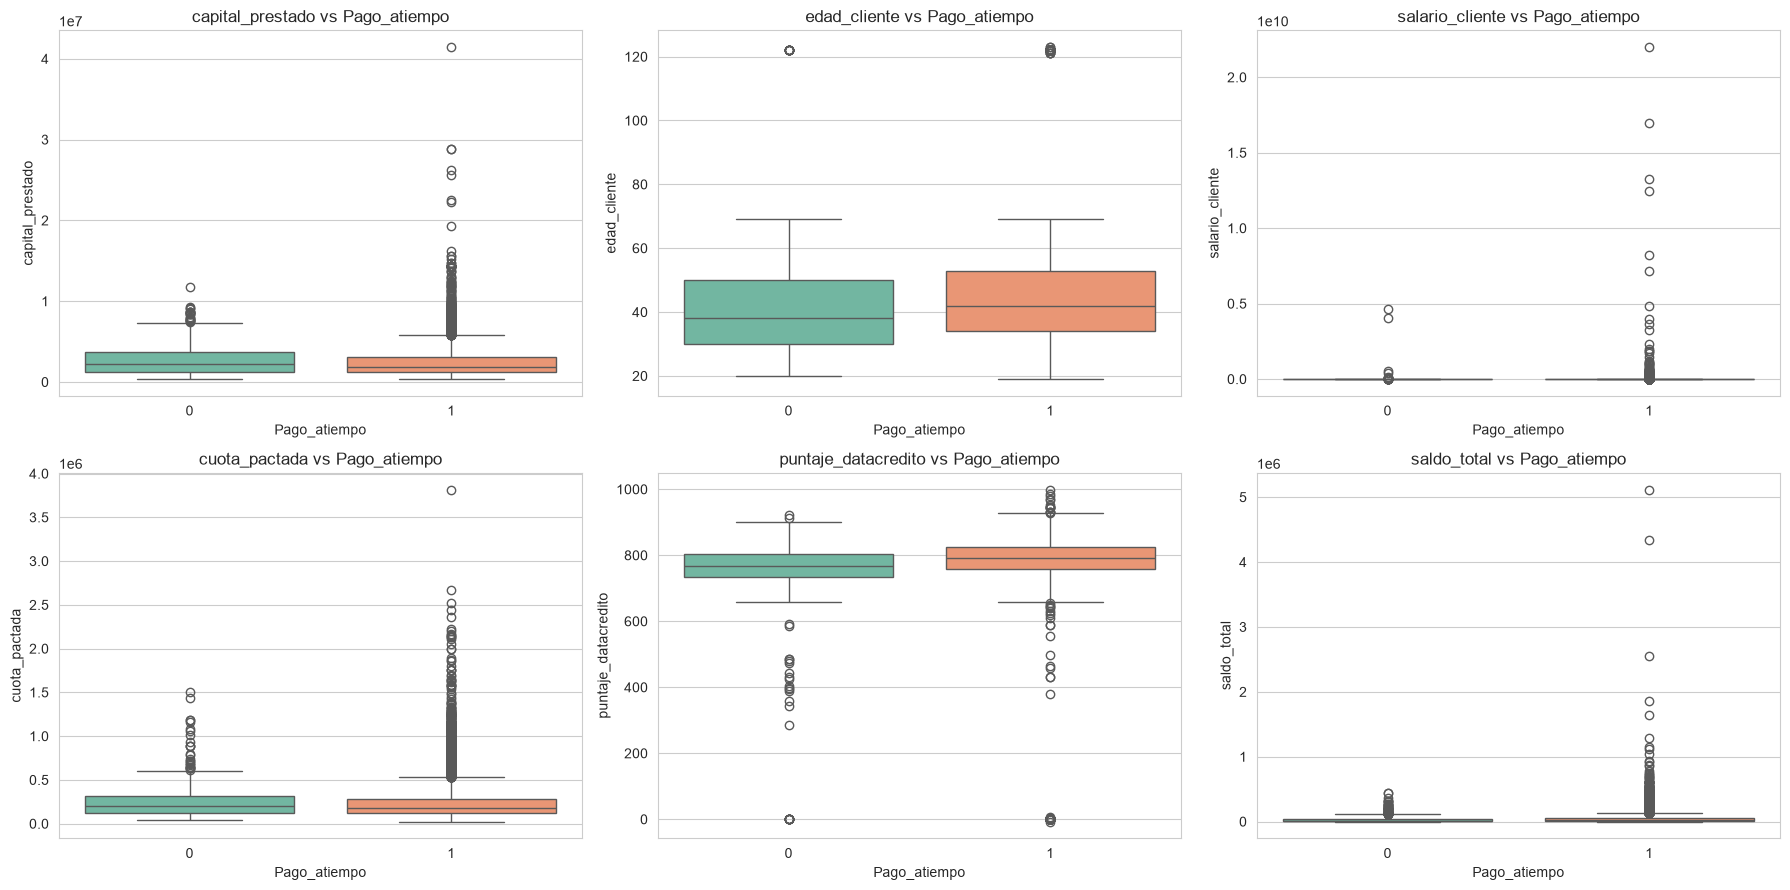

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, col in zip(axes.flatten(), num_vars):
    sns.boxplot(x='Pago_atiempo', y=col, data=df, ax=ax, hue='Pago_atiempo', palette='Set2', legend=False)
    ax.set_title(f'{col} vs Pago_atiempo')
plt.tight_layout()
plt.show()

In [20]:
tabla_pivote = df.groupby('Pago_atiempo')[num_vars].median().T
tabla_pivote.columns = ['Mediana - No paga a tiempo (0)', 'Mediana - Paga a tiempo (1)']
tabla_pivote

,Mediana - No paga a tiempo (0),Mediana - Paga a tiempo (1)
capital_prestado,2268000.0,1908446.4
edad_cliente,38.0,42.0
salario_cliente,3000000.0,3000000.0
cuota_pactada,199002.0,182576.0
puntaje_datacredito,768.0,792.0
saldo_total,14518.5,16308.0


**Interpretación:** se observa que los clientes que **no** pagan a tiempo tienden a tener `saldo_total` y `cuota_pactada` más altos en mediana, lo que es consistente con un mayor nivel de endeudamiento asociado al incumplimiento. La diferencia en `edad_cliente` y `salario_cliente` entre ambos grupos es menos marcada.

In [21]:
for col in ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos_limpia']:
    tabla_cruzada = pd.crosstab(df[col], df['Pago_atiempo'], normalize='index') * 100
    tabla_cruzada.columns = ['% No paga a tiempo', '% Paga a tiempo']
    print(f"--- {col} vs Pago_atiempo (%) ---")
    print(tabla_cruzada.round(2))
    print()

--- tipo_credito vs Pago_atiempo (%) ---
              % No paga a tiempo  % Paga a tiempo
tipo_credito                                     
4                           4.69            95.31
6                          42.86            57.14
7                           0.00           100.00
9                           4.73            95.27
10                          2.59            97.41
68                          0.00           100.00

--- tipo_laboral vs Pago_atiempo (%) ---
               % No paga a tiempo  % Paga a tiempo
tipo_laboral                                      
Empleado                     4.29            95.71
Independiente                5.51            94.49

--- tendencia_ingresos_limpia vs Pago_atiempo (%) ---
                           % No paga a tiempo  % Paga a tiempo
tendencia_ingresos_limpia                                     
Creciente                                3.91            96.09
Decreciente                              6.27            93.73
Establ

**Interpretación:** ninguna categoría de `tipo_laboral` o `tipo_credito` muestra una tasa de incumplimiento dramáticamente distinta al promedio general (~5%), lo que sugiere que estas variables por sí solas tienen poder predictivo moderado — probablemente aporten más en combinación con variables de comportamiento financiero (saldos, mora, puntaje).

## 5. Análisis multivariable

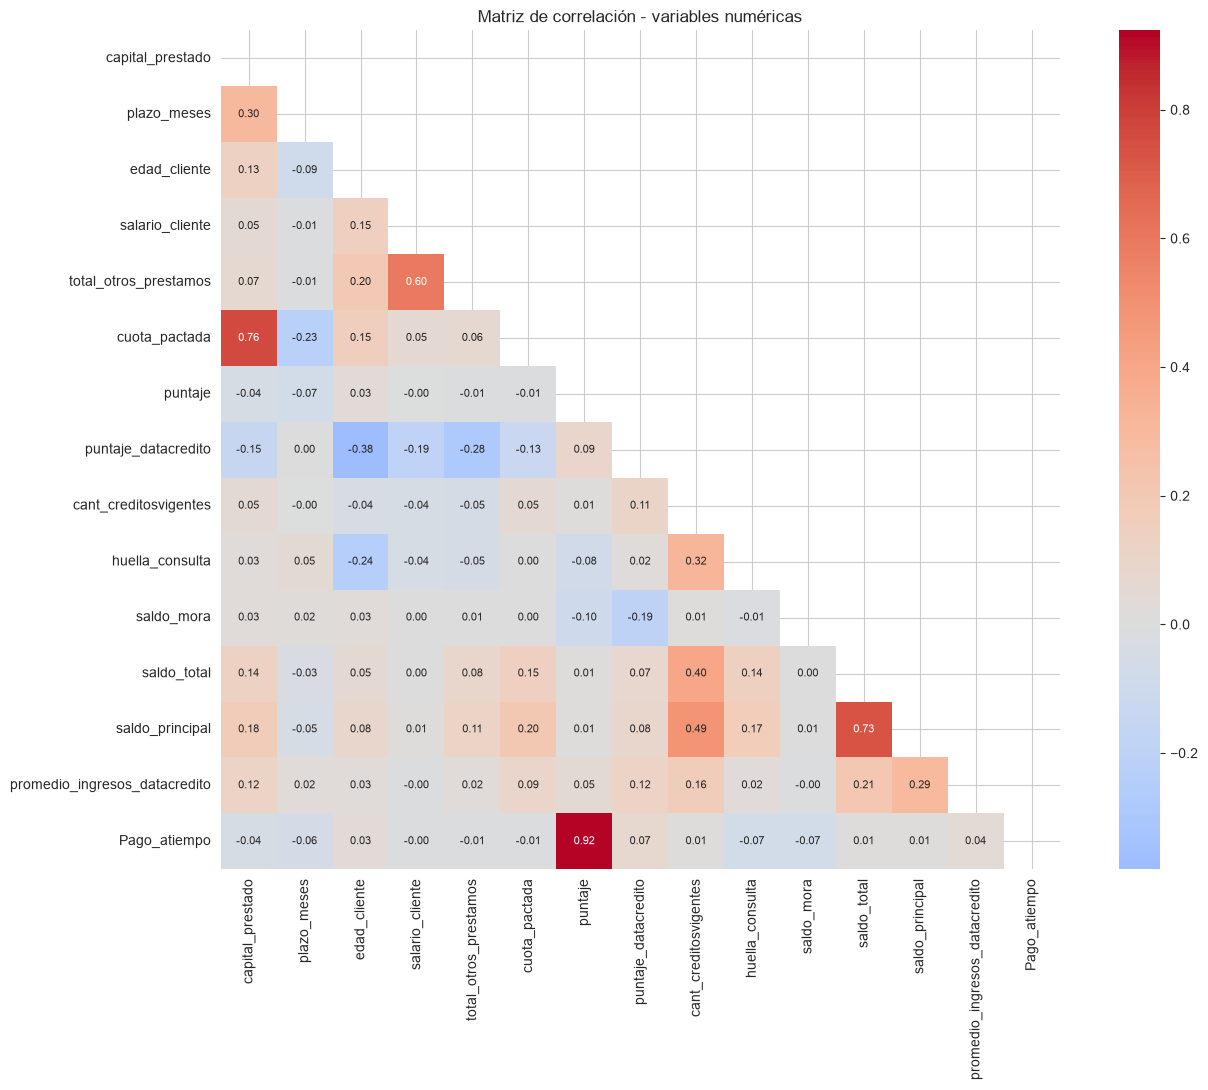

In [22]:
corr_vars = ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
             'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito',
             'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total',
             'saldo_principal', 'promedio_ingresos_datacredito', 'Pago_atiempo']

corr_matrix = df[corr_vars].corr()

# Máscara para ocultar el triángulo superior y dejar solo la diagonal inferior visible
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, annot_kws={'size': 8}, square=True)
ax.set_title('Matriz de correlación - variables numéricas')
plt.tight_layout()
plt.show()

**Interpretación:** se observa una correlación muy alta (**0.92**) entre `puntaje` y `Pago_atiempo`, muy por encima del resto de las relaciones de la matriz — incluso muy por encima de `puntaje_datacredito` (0.07), que es la otra variable de scoring disponible. Según el diccionario de datos, `puntaje` es "otra fuente de score para evaluar al cliente", sin más precisión sobre cómo se calcula. Que sea un score legítimo no explica por sí solo una correlación casi perfecta con el resultado real de pago: si fuera un score predictivo genuino (como `puntaje_datacredito`), se esperaría una correlación alta pero no de esta magnitud. Esto sigue siendo una señal fuerte de **posible data leakage**: hay que verificar con el equipo de datos si `puntaje` se calculó usando información posterior o derivada del propio resultado de pago (`Pago_atiempo`). De confirmarse, `puntaje` debería excluirse como feature de entrenamiento, ya que el modelo no tendría ese dato disponible al momento real de la predicción (para un cliente nuevo, cuyo pago todavía no ocurrió).

Dejando de lado ese caso puntual, `saldo_total` y `saldo_principal` muestran una correlación alta entre sí (esperable, ya que uno es componente del otro) — candidatos a evaluar redundancia en feature engineering. `capital_prestado` y `cuota_pactada` también correlacionan fuertemente (a mayor capital, mayor cuota, lógico). Fuera de `puntaje`, ninguna otra variable numérica muestra una correlación fuerte y aislada con `Pago_atiempo`, lo que sugiere que el patrón de incumplimiento —descontando ese posible leakage— es multivariado y no se explica por una sola variable.

## 6. Reglas de validación de datos identificadas

A partir de este análisis, se proponen las siguientes reglas de validación para etapas posteriores del pipeline:

1. `tendencia_ingresos` solo puede tomar los valores `{Estable, Creciente, Decreciente}` o nulo. Cualquier otro valor es un error de origen.
2. `Pago_atiempo` debe ser estrictamente binaria (0/1), sin nulos y sin duplicados de fila asociados.
3. `edad_cliente` debe estar en un rango razonable (ej. 18-90 años). Se detectaron 150 registros fuera de este rango (hasta 123 años) que deben revisarse en el origen de datos.
4. Las variables monetarias (`capital_prestado`, `salario_cliente`, `cuota_pactada`, `saldo_total`, `saldo_principal`) deben ser ≥ 0.
5. `tipo_credito` debe pertenecer al conjunto cerrado de códigos observados: {4, 6, 7, 9, 10, 68}. Un valor fuera de este conjunto debería alertar sobre un nuevo tipo de crédito no contemplado.
6. El dataset no debe contener filas completamente duplicadas (`df.duplicated()` debe ser 0).

## 7. Transformaciones identificadas

- Las variables monetarias con skewness alto (`capital_prestado`, `salario_cliente`, `cuota_pactada`, `saldo_total`) son candidatas a transformación logarítmica (`log1p`) para reducir el efecto de los outliers antes de entrenar modelos lineales.
- **Revisar el origen de `puntaje` antes de usarla como feature**: su correlación de 0.92 con `Pago_atiempo` es un indicio de posible data leakage (ver sección de análisis multivariable). Si se confirma que se calcula a partir del resultado de pago, debe excluirse del modelo.
- `tipo_credito` y `tipo_laboral` requieren codificación categórica (One-Hot Encoding o similar) para ser usadas en modelos de ML.
- Imputación pendiente para `tendencia_ingresos_limpia` y `promedio_ingresos_datacredito` (~27% de nulos) — evaluar imputación por moda/mediana o un modelo de imputación más sofisticado, dado el volumen de nulos.
- Fuerte desbalance de clases en `Pago_atiempo` (~95/5) — requiere estrategia de balanceo (SMOTE, undersampling, o ajuste de `class_weight`) en la etapa de entrenamiento.

## 8. Atributos adicionales sugeridos (feature engineering)

- **Relación cuota/salario** (`cuota_pactada / salario_cliente`): proxy de nivel de endeudamiento relativo al ingreso.
- **Ratio saldo_mora / saldo_total**: proporción del saldo que está en mora.
- **Total de créditos en todos los sectores** (`creditos_sectorFinanciero + creditos_sectorCooperativo + creditos_sectorReal`): exposición crediticia total del cliente.
- **Bandera de dato faltante** para `tendencia_ingresos_limpia` y `promedio_ingresos_datacredito`: el hecho de que falte el dato podría ser en sí mismo informativo.

> **Nota sobre features descartadas:** se había considerado inicialmente una feature de "antigüedad del préstamo" (`hoy - fecha_prestamo`). Se descarta: el objetivo del proyecto es predecir el comportamiento de **clientes nuevos**, quienes por definición todavía no tienen `fecha_prestamo` al momento de la predicción (el crédito aún no fue otorgado). Esta feature solo tendría sentido para análisis histórico, no como input real de un modelo de scoring para nuevos clientes.

## 9. Conclusiones generales

El dataset está en condiciones de avanzar a la etapa de *feature engineering*, una vez resueltos los puntos de imputación de nulos y la corrección definitiva de `tendencia_ingresos`. El hallazgo más relevante para el modelado es el fuerte desbalance de la variable objetivo, que deberá abordarse explícitamente para evitar un modelo sesgado hacia la clase mayoritaria, junto con la verificación pendiente de posible data leakage en `puntaje`.